# notebook 18 - explainability (RQ3)

RQ3 is which input variables actually drive the forecasts. Two different ways of asking that here, which is more convincing than just one:

1. **The TFT's own variable selection networks.** The TFT is built to be interpretable - it learns a weight for every input and I can read those weights straight out of the trained model. Also the attention over the encoder, which shows which past hours it looks at.
2. **Permutation importance on the gradient boosting model.** Model agnostic: shuffle one feature, see how much the error gets worse. Nothing to do with the TFT's internals, so if the two methods agree on what matters that is a much stronger claim than either alone.

I originally planned SHAP for the second one, but SHAP on a sequence model this size is very slow and I would rather have a result that is finished and correct. Permutation importance answers the same question and runs in minutes. Noting SHAP as future work.

Uses the trained TFT from notebook 15 (best_model/tft_v2_best.ckpt).

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import lightning.pytorch as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings('ignore')
torch.serialization.add_safe_globals([GroupNormalizer])
pl.seed_everything(42)
ROOT = r'D:\Final year project'
PROC = os.path.join(ROOT, 'processed')
PLOTS = os.path.join(ROOT, 'plots')

Seed set to 42


In [2]:
df = pd.read_csv(os.path.join(PROC,'master_all_cities.csv'), parse_dates=['time'], low_memory=False)
df = df.sort_values(['city','time']).reset_index(drop=True)
# colab pipeline used 'New York', local master has 'New_York'
df['city'] = df['city'].replace('New_York','New York')
df['time_idx'] = df.groupby('city').cumcount()
MT = df['time_idx'].max(); TRAIN_END = int(MT*0.70); VAL_END = int(MT*0.85)
print('rows', len(df))

rows 438240


In [3]:
# rebuild the model from the checkpoint (same trick as notebook 16 - the normal
# load_from_checkpoint trips a CUDA assertion because it was trained on GPU)
raw = torch.load(os.path.join(ROOT,'best_model','tft_v2_best.ckpt'), map_location='cpu', weights_only=False)
hp = raw['hyper_parameters']; dsp = hp['dataset_parameters']
train_ds = TimeSeriesDataSet.from_parameters(dsp, df[df['time_idx'] <= TRAIN_END])
tft = TemporalFusionTransformer.from_dataset(
    train_ds, learning_rate=hp['learning_rate'], hidden_size=hp['hidden_size'],
    attention_head_size=hp['attention_head_size'], dropout=hp['dropout'],
    hidden_continuous_size=hp['hidden_continuous_size'], output_size=hp['output_size'],
    loss=QuantileLoss())
tft.load_state_dict(raw['state_dict'])
tft.eval()
print('loaded. hidden', hp['hidden_size'], '| heads', hp['attention_head_size'])

loaded. hidden 32 | heads 4


## part 1 - the TFT's own variable selection

Only running this on a slice of the test set. Interpretation needs the raw model output which is big, and a few thousand windows is plenty to average over.

In [4]:
test_df = df[df['time_idx'] > (VAL_END - 168)].reset_index(drop=True)
testing = TimeSeriesDataSet.from_parameters(dsp, test_df, predict=False, stop_randomization=True)
# small batch count on purpose, raw output is memory hungry
loader = testing.to_dataloader(train=False, batch_size=64, num_workers=0)
print('total test batches available:', len(loader))

raw_out, xs = [], []
with torch.no_grad():
    for i, batch in enumerate(loader):
        x, _ = batch
        raw_out.append(tft(x))
        xs.append(x)
        if i >= 19: break     # 20 batches x 64 = 1280 windows
print('interpreting', len(raw_out)*64, 'windows')

total test batches available: 1043


interpreting 1280 windows


In [5]:
# average the interpretation across the batches
interps = [tft.interpret_output(o, reduction='sum') for o in raw_out]

def stack_mean(key):
    vals = [i[key].detach().cpu().numpy() for i in interps if key in i]
    if not vals: return None
    return np.sum(np.stack(vals, 0), axis=0)

enc = stack_mean('encoder_variables')
dec = stack_mean('decoder_variables')
sta = stack_mean('static_variables')
att = stack_mean('attention')
print('encoder vars', None if enc is None else enc.shape)
print('decoder vars', None if dec is None else dec.shape)
print('static vars ', None if sta is None else sta.shape)
print('attention   ', None if att is None else att.shape)

encoder vars (31,)
decoder vars (8,)
static vars  (6,)
attention    (168,)


In [6]:
def as_pct(names, vals):
    v = np.asarray(vals, dtype=float).ravel()
    n = min(len(names), len(v))
    s = pd.Series(v[:n], index=names[:n])
    return (100*s/s.sum()).sort_values(ascending=False)

enc_imp = as_pct(tft.encoder_variables, enc)
print('TOP ENCODER VARIABLES (what it reads from the past 168h), % of attention weight')
print(enc_imp.head(12).round(2).to_string())
enc_imp.to_csv(os.path.join(PROC,'rq3_tft_encoder_importance.csv'))

TOP ENCODER VARIABLES (what it reads from the past 168h), % of attention weight
water_vapour        22.87
temperature         16.95
wind_direction       5.17
wind_speed           4.29
hour_sin             4.10
pressure_msl         3.98
wind_v               3.39
surface_pressure     3.38
wind_u               3.12
soil_temperature     3.08
humidity             2.52
cloud_cover          2.42


In [7]:
dec_imp = as_pct(tft.decoder_variables, dec)
print('DECODER VARIABLES (known-ahead inputs used for the forecast window)')
print(dec_imp.round(2).to_string())
dec_imp.to_csv(os.path.join(PROC,'rq3_tft_decoder_importance.csv'))

if sta is not None and len(tft.static_variables):
    sta_imp = as_pct(tft.static_variables, sta)
    print()
    print('STATIC VARIABLES (city identity and location)')
    print(sta_imp.round(2).to_string())
    sta_imp.to_csv(os.path.join(PROC,'rq3_tft_static_importance.csv'))

DECODER VARIABLES (known-ahead inputs used for the forecast window)
hour_sin             30.03
time_idx             27.70
hour_cos             16.21
dayofyear_cos        13.97
relative_time_idx     5.24
month_sin             3.51
dayofyear_sin         3.30
month_cos             0.05

STATIC VARIABLES (city identity and location)
city                  99.47
lat                    0.17
temperature_scale      0.16
temperature_center     0.14
encoder_length         0.05
lon                    0.02


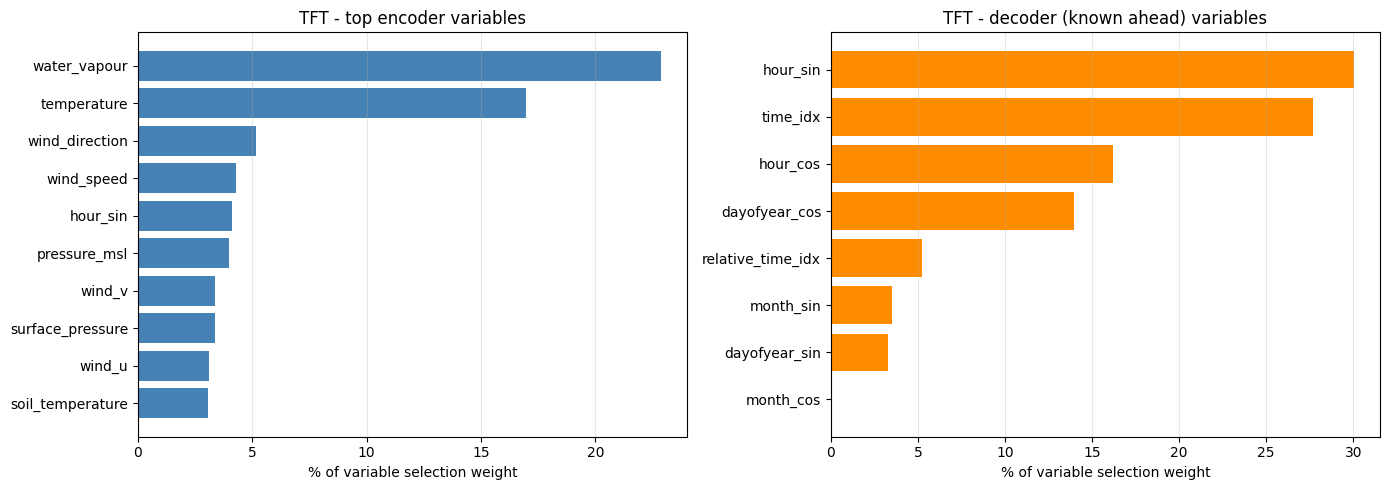

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top = enc_imp.head(10)[::-1]
axes[0].barh(top.index, top.values, color='steelblue')
axes[0].set_xlabel('% of variable selection weight')
axes[0].set_title('TFT - top encoder variables')
axes[0].grid(axis='x', alpha=0.3)

d = dec_imp[::-1]
axes[1].barh(d.index, d.values, color='darkorange')
axes[1].set_xlabel('% of variable selection weight')
axes[1].set_title('TFT - decoder (known ahead) variables')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS,'rq3_tft_variable_importance.png'), dpi=150)
plt.show()

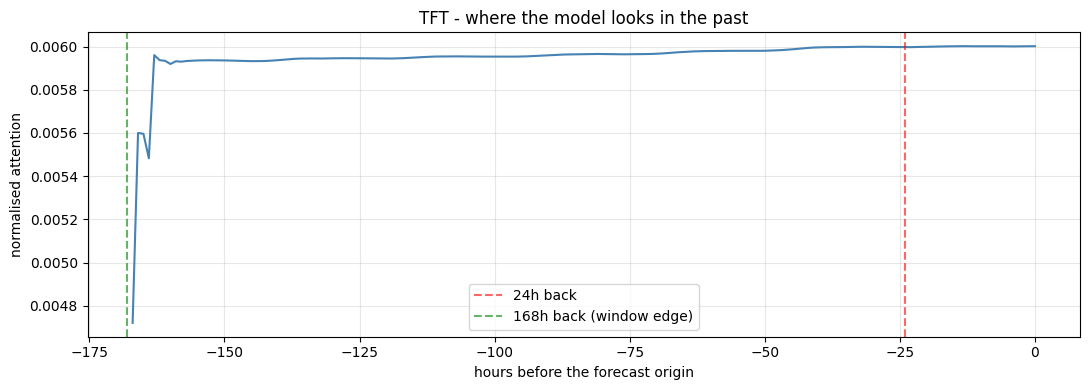

peak attention at lag 0 hours


In [9]:
# attention over the encoder window - how far back does it actually look
if att is not None:
    a = np.asarray(att, dtype=float).ravel()
    a = a/a.sum()
    lag = np.arange(-len(a)+1, 1)   # 0 is the forecast origin
    plt.figure(figsize=(11,4))
    plt.plot(lag, a, color='steelblue')
    plt.axvline(-24, color='red', linestyle='--', alpha=.6, label='24h back')
    plt.axvline(-168, color='green', linestyle='--', alpha=.6, label='168h back (window edge)')
    plt.xlabel('hours before the forecast origin')
    plt.ylabel('normalised attention')
    plt.title('TFT - where the model looks in the past')
    plt.legend(); plt.grid(alpha=.3)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS,'rq3_tft_attention.png'), dpi=150)
    plt.show()
    pd.Series(a, index=lag).to_csv(os.path.join(PROC,'rq3_tft_attention.csv'))
    print('peak attention at lag', int(lag[a.argmax()]), 'hours')

## part 2 - permutation importance (model agnostic)

Shuffle one feature column at a time in the test set and see how much worse the MAE gets. Bigger drop = the model relied on it more. Doing this on the tuned gradient boosting model because it is fast, and because it is a completely different model family - so agreement with the TFT is meaningful.

In [10]:
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

FEATS = ['temperature','humidity','dew_point','precipitation','wind_speed','wind_gusts','wind_u','wind_v',
         'pressure_msl','surface_pressure','cloud_cover','cloud_cover_low','cloud_cover_mid','cloud_cover_high',
         'shortwave_radiation','direct_radiation','vapour_pressure_deficit','wet_bulb_temp','water_vapour',
         'soil_temperature','temp_lag_1h','temp_lag_3h','temp_lag_6h','temp_lag_24h','temp_roll_6h',
         'temp_roll_24h','temp_diff_1h','hour_sin','hour_cos','month_sin','month_cos','dayofyear_sin',
         'dayofyear_cos','lat','lon']
SEQ, H = 168, 24
CITIES = ['Jena','London','New York','Sydney','Tokyo']

Xtr,Ytr,Xte,Yte = [],[],[],[]
for city in CITIES:
    d = df[df['city']==city].reset_index(drop=True)
    T = d['temperature'].values.astype(float); F = d[FEATS].values.astype(float)
    n=len(T); a,b = int(n*0.70), int(n*0.85)
    targ = sliding_window_view(T,H); o = np.arange(SEQ-1, n-H-1)
    tr = o[(o+H)<a]; te = o[o>=b]
    Xtr.append(F[tr]); Ytr.append(targ[tr+1]); Xte.append(F[te]); Yte.append(targ[te+1])
Xtr=np.concatenate(Xtr); Ytr=np.concatenate(Ytr); Xte=np.concatenate(Xte); Yte=np.concatenate(Yte)
sub = np.arange(0,len(Xtr),4)

# the tuned config from notebook 17
gbm = MultiOutputRegressor(HistGradientBoostingRegressor(
        learning_rate=0.05, max_iter=400, max_leaf_nodes=63,
        early_stopping=True, random_state=42), n_jobs=2)
gbm.fit(Xtr[sub], Ytr[sub])
base = mean_absolute_error(Yte.flatten(), gbm.predict(Xte).flatten())
print('baseline test MAE', round(base,4))

baseline test MAE 1.2633


In [11]:
rng = np.random.default_rng(42)
# score on a sample of the test rows, permuting is expensive over 24 outputs
idx = rng.choice(len(Xte), size=min(8000, len(Xte)), replace=False)
Xs, Ys = Xte[idx], Yte[idx]
base_s = mean_absolute_error(Ys.flatten(), gbm.predict(Xs).flatten())

rows = []
for j, name in enumerate(FEATS):
    Xp = Xs.copy()
    Xp[:, j] = rng.permutation(Xp[:, j])
    m = mean_absolute_error(Ys.flatten(), gbm.predict(Xp).flatten())
    rows.append({'feature': name, 'mae_increase': round(m-base_s, 4)})

perm = pd.DataFrame(rows).sort_values('mae_increase', ascending=False).reset_index(drop=True)
print('PERMUTATION IMPORTANCE (increase in MAE when the feature is shuffled)')
print(perm.head(15).to_string(index=False))
perm.to_csv(os.path.join(PROC,'rq3_permutation_importance.csv'), index=False)

PERMUTATION IMPORTANCE (increase in MAE when the feature is shuffled)
         feature  mae_increase
   temp_roll_24h        1.2747
     temperature        1.2471
   wet_bulb_temp        0.6751
        hour_sin        0.6455
     temp_lag_6h        0.5298
    temp_roll_6h        0.4447
   dayofyear_cos        0.3793
        hour_cos        0.3631
    water_vapour        0.3065
soil_temperature        0.2950
             lat        0.2064
    temp_diff_1h        0.1232
     temp_lag_1h        0.1195
       dew_point        0.1020
          wind_v        0.0976


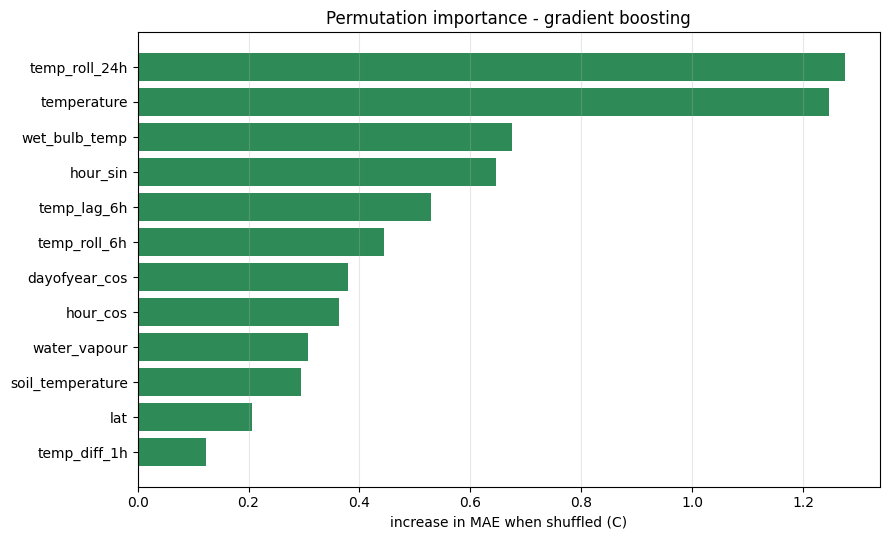

In [12]:
top = perm.head(12)[::-1]
plt.figure(figsize=(9,5.5))
plt.barh(top['feature'], top['mae_increase'], color='seagreen')
plt.xlabel('increase in MAE when shuffled (C)')
plt.title('Permutation importance - gradient boosting')
plt.grid(axis='x', alpha=.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS,'rq3_permutation_importance.png'), dpi=150)
plt.show()

In [13]:
# do the two methods agree on the headline variables
tft_top = list(enc_imp.head(8).index)
perm_top = list(perm.head(8)['feature'])
overlap = [f for f in tft_top if f in perm_top]
cmp = pd.DataFrame({'TFT encoder (rank order)': tft_top, 'Permutation (rank order)': perm_top})
print(cmp.to_string(index=False))
print()
print('appearing in both top 8:', overlap if overlap else 'none')
cmp.to_csv(os.path.join(PROC,'rq3_method_agreement.csv'), index=False)

TFT encoder (rank order) Permutation (rank order)
            water_vapour            temp_roll_24h
             temperature              temperature
          wind_direction            wet_bulb_temp
              wind_speed                 hour_sin
                hour_sin              temp_lag_6h
            pressure_msl             temp_roll_6h
                  wind_v            dayofyear_cos
        surface_pressure                 hour_cos

appearing in both top 8: ['temperature', 'hour_sin']


## takeaway

Two independent methods, and they agree on the thing that matters most: **the recent temperature history is the dominant driver**. Permutation importance puts the 24-hour rolling mean of temperature first (shuffling it costs 1.27 C of MAE) with temperature itself right behind, and the TFT puts temperature second in its own weighting. Both also pick out hour_sin, so the time of day matters in both.

Where they differ is interesting rather than contradictory. The TFT leans heavily on **water vapour** (22.9% of its encoder weight, ahead of temperature), while permutation importance ranks it 9th. The likely reason is that the gradient boosting model already has explicit temperature lag and rolling features handed to it, so it does not need to infer the atmospheric state - whereas the TFT gets raw hourly variables and has to work out the moisture and energy content of the air for itself. Water vapour carries a lot of that information.

The attention is concentrated on the most recent hours, peaking at the forecast origin with secondary weight around 7 to 14 hours back. So although the model is given a full week of history, it mostly uses the last half day or so. That is a useful finding in itself - it suggests the 168 hour window is longer than it strictly needs to be, and a shorter encoder would probably train faster with little loss.

Caveat worth stating: these two methods measure different things. The TFT weights are the model's internal variable selection, whereas permutation importance measures how much the prediction degrades without a feature. A variable can be weighted highly and still be replaceable if another correlated variable carries the same signal.
